# Fraud Yelp: symmetric degree-normalized similarity-weighted MPLE

This notebook corrects the previous row-normalized graph term. The corrected interaction normalizes by both endpoints:
$$
\frac{A_{ij}^{(r)} w_{ij}^{(r)}}{\sqrt{D_i^{(r)}D_j^{(r)}}},
\qquad
D_i^{(r)}=\sum_k A_{ik}^{(r)}w_{ik}^{(r)}.
$$


In [46]:
# If needed, install a consistent PyTorch/DGL stack and restart once.
import importlib.metadata as md
import os
import subprocess
import sys

TARGETS = {
    "torch": "2.4.0",
    "torchvision": "0.19.0",
    "torchaudio": "2.4.0",
    "torchdata": "0.8.0",
}

def installed_version(package):
    try:
        return md.version(package).split("+")[0]
    except md.PackageNotFoundError:
        return None

needs_install = any(installed_version(pkg) != ver for pkg, ver in TARGETS.items())
needs_install = needs_install or installed_version("dgl") is None

if needs_install:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall",
        *(f"{pkg}=={ver}" for pkg, ver in TARGETS.items()),
    ])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall",
        "dgl", "-f", "https://data.dgl.ai/wheels/torch-2.4/repo.html",
    ])
    print("Installed compatible PyTorch/DGL packages. Restarting the kernel; rerun the notebook from the top.")
    os.kill(os.getpid(), 9)
else:
    print("Compatible PyTorch/DGL packages are already installed.")

%pip install -q scikit-learn pandas matplotlib

Compatible PyTorch/DGL packages are already installed.


In [47]:
import random, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix
)

import dgl
from dgl.data import FraudYelpDataset

SEED = 717
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Corrected model

The corrected model is
$$
\mathbb P_{\beta,\theta}(\sigma\mid X,G_1,G_2,G_3)
\propto
\exp\left\{
\sum_{r=1}^3
\beta_r
\sum_{i<j}
\frac{
A_{ij}^{(r)}
\exp\left(-\frac{\|X_i-X_j\|_2^2}{2\tau_r^2}\right)
}{
\sqrt{
\left[\sum_{k=1}^n A_{ik}^{(r)}
\exp\left(-\frac{\|X_i-X_k\|_2^2}{2\tau_r^2}\right)+\varepsilon\right]
\left[\sum_{k=1}^n A_{jk}^{(r)}
\exp\left(-\frac{\|X_j-X_k\|_2^2}{2\tau_r^2}\right)+\varepsilon\right]
}
}
\sigma_i\sigma_j
+
2\sum_{i=1}^n\sigma_i b_\theta(X_i)
\right\}.
$$

The notebook trains the corresponding pseudo-likelihood classifier. For validation/test prediction, only training labels are used as observed neighboring spins.


In [48]:
dataset = FraudYelpDataset(random_seed=SEED, train_size=0.7, val_size=0.1, verbose=True)
g = dataset[0]

print(g)
print("node types:", g.ntypes)
print("edge types:", g.etypes)
print("canonical edge types:", g.canonical_etypes)


Done loading data from cached files.
Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
node types: ['review']
edge types: ['net_rsr', 'net_rtr', 'net_rur']
canonical edge types: [('review', 'net_rsr', 'review'), ('review', 'net_rtr', 'review'), ('review', 'net_rur', 'review')]


In [49]:
def get_node_data(g, key, ntype=None):
    if ntype is None:
        if len(g.ntypes) != 1:
            raise ValueError("Pass ntype explicitly when graph has multiple node types.")
        ntype = g.ntypes[0]
    value = g.ndata[key]
    if isinstance(value, dict):
        return value[ntype]
    return value

ntype = g.ntypes[0]

X_raw = get_node_data(g, "feature", ntype).float()
y01 = get_node_data(g, "label", ntype).long()
train_mask = get_node_data(g, "train_mask", ntype).bool()
val_mask = get_node_data(g, "val_mask", ntype).bool()
test_mask = get_node_data(g, "test_mask", ntype).bool()

sigma_all = 2.0 * y01.float() - 1.0

summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "n": [int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()), int(y01.numel())],
    "positives_label_1": [int(y01[train_mask].sum()), int(y01[val_mask].sum()), int(y01[test_mask].sum()), int(y01.sum())],
})
summary["positive_rate"] = summary["positives_label_1"] / summary["n"]
summary


,split,n,positives_label_1,positive_rate
0,train,32167,4726,0.146921
1,validation,4595,651,0.141676
2,test,9192,1300,0.141427
3,all,45954,6677,0.145297


In [50]:
EDGE_TYPES = ["net_rur", "net_rsr", "net_rtr"]
BETA_LABELS = ["beta_1: net_rur", "beta_2: net_rsr", "beta_3: net_rtr"]

missing = [e for e in EDGE_TYPES if e not in g.etypes]
if missing:
    raise ValueError(f"Missing expected edge types: {missing}. Present edge types: {g.etypes}")

for etype in EDGE_TYPES:
    print(f"{etype:8s}: {g.num_edges(etype=etype):,} directed edges")


net_rur : 98,630 directed edges
net_rsr : 6,805,486 directed edges
net_rtr : 1,147,232 directed edges


In [51]:
def standardize_with_train_stats(X, train_mask, eps=1e-12):
    X = X.float()
    mean = X[train_mask].mean(dim=0)
    std = X[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
    return (X - mean) / std, mean, std

X, X_mean, X_std = standardize_with_train_stats(X_raw, train_mask)
print("raw feature shape:", tuple(X_raw.shape))
print("standardized feature shape:", tuple(X.shape))


raw feature shape: (45954, 32)
standardized feature shape: (45954, 32)


## Compute symmetric normalized graph signal

For each relation \(r\), the graph covariate used for node \(i\) is
$$
\sum_j
\frac{A_{ij}^{(r)}w_{ij}^{(r)}}{\sqrt{(D_i^{(r)}+\varepsilon)(D_j^{(r)}+\varepsilon)}}
\sigma_j^{\mathrm{obs}}.
$$
This is the corrected normalization: both endpoints \(i\) and \(j\) enter.


In [52]:
SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = train_mask
# SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = torch.ones_like(train_mask, dtype=torch.bool)  # oracle diagnostic

EDGE_CHUNK_SIZE = 500_000
TAU_SAMPLE_SIZE = 200_000
DEGREE_EPS = 1e-12

@torch.no_grad()
def estimate_relation_taus_from_edge_samples(g, X_for_similarity, edge_types, sample_size=200_000, seed=717, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rng = np.random.default_rng(seed)
    X_dev = X_for_similarity.to(device).float()
    tau_values = []

    for etype in edge_types:
        src, dst = g.edges(etype=etype)
        m = src.numel()
        if m == 0:
            tau_values.append(1.0)
            continue
        k = min(sample_size, m)
        sample_idx = rng.choice(m, size=k, replace=False)
        src_s, dst_s = src[sample_idx].to(device), dst[sample_idx].to(device)
        dist = (X_dev[src_s] - X_dev[dst_s]).pow(2).sum(dim=1).sqrt()
        tau = torch.median(dist).item()
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = float(dist.mean().item())
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = 1.0
        tau_values.append(float(tau))

    return torch.tensor(tau_values, dtype=torch.float32)

@torch.no_grad()
def rbf_edge_weights(X_dev, src, dst, tau):
    dist2 = (X_dev[src] - X_dev[dst]).pow(2).sum(dim=1)
    return torch.exp(-dist2 / (2.0 * float(tau) ** 2))

@torch.no_grad()
def compute_weighted_degrees(g, X_for_similarity, edge_types, tau_values, chunk_size=500_000, eps=1e-12, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_dev = X_for_similarity.to(device).float()
    n = X_for_similarity.shape[0]
    degree_columns = []

    for r, etype in enumerate(edge_types):
        src_cpu, dst_cpu = g.edges(etype=etype)
        deg = torch.zeros(n, dtype=torch.float32, device=device)
        tau_r = float(tau_values[r])

        for start in range(0, src_cpu.numel(), chunk_size):
            end = min(start + chunk_size, src_cpu.numel())
            src = src_cpu[start:end].to(device)
            dst = dst_cpu[start:end].to(device)
            w = rbf_edge_weights(X_dev, src, dst, tau=tau_r)
            deg.index_add_(0, dst, w)

        degree_columns.append(deg.clamp_min(eps).cpu())

    return torch.stack(degree_columns, dim=1)

@torch.no_grad()
def compute_symmetric_normalized_neighbor_sums(
    g, sigma_all, observed_mask, X_for_similarity, edge_types, tau_values, weighted_degrees,
    chunk_size=500_000, eps=1e-12, device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_dev = X_for_similarity.to(device).float()
    sigma_dev = sigma_all.to(device).float()
    obs_dev = observed_mask.to(device).bool()
    D_dev = weighted_degrees.to(device).float().clamp_min(eps)

    n = sigma_all.numel()
    columns = []

    for r, etype in enumerate(edge_types):
        src_cpu, dst_cpu = g.edges(etype=etype)
        out = torch.zeros(n, dtype=torch.float32, device=device)
        tau_r = float(tau_values[r])

        for start in range(0, src_cpu.numel(), chunk_size):
            end = min(start + chunk_size, src_cpu.numel())
            src = src_cpu[start:end].to(device)
            dst = dst_cpu[start:end].to(device)

            w = rbf_edge_weights(X_dev, src, dst, tau=tau_r)
            coeff = w / torch.sqrt(D_dev[dst, r] * D_dev[src, r])
            out.index_add_(0, dst, coeff * obs_dev[src].float() * sigma_dev[src])

        columns.append(out.cpu())

    return torch.stack(columns, dim=1)


In [53]:
tau_values = estimate_relation_taus_from_edge_samples(
    g=g, X_for_similarity=X, edge_types=EDGE_TYPES,
    sample_size=TAU_SAMPLE_SIZE, seed=SEED, device=device
)

pd.DataFrame({"edge_type": EDGE_TYPES, "tau_r": tau_values.numpy()})


,edge_type,tau_r
0,net_rur,6.746763
1,net_rsr,7.590441
2,net_rtr,7.569873


In [54]:
weighted_degrees = compute_weighted_degrees(
    g=g, X_for_similarity=X, edge_types=EDGE_TYPES, tau_values=tau_values,
    chunk_size=EDGE_CHUNK_SIZE, eps=DEGREE_EPS, device=device
)

pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "mean_weighted_degree_train": weighted_degrees[train_mask].mean(dim=0).numpy(),
    "median_weighted_degree_train": weighted_degrees[train_mask].median(dim=0).values.numpy(),
    "fraction_zero_degree_train": (weighted_degrees[train_mask] <= DEGREE_EPS).float().mean(dim=0).numpy(),
})


,edge_type,mean_weighted_degree_train,median_weighted_degree_train,fraction_zero_degree_train
0,net_rur,1.296849,0.435305,0.483197
1,net_rsr,89.155907,89.288231,0.000839
2,net_rtr,15.040526,13.462767,0.011534


In [55]:
S_sym = compute_symmetric_normalized_neighbor_sums(
    g=g,
    sigma_all=sigma_all,
    observed_mask=SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS,
    X_for_similarity=X,
    edge_types=EDGE_TYPES,
    tau_values=tau_values,
    weighted_degrees=weighted_degrees,
    chunk_size=EDGE_CHUNK_SIZE,
    eps=DEGREE_EPS,
    device=device,
)

pd.DataFrame(S_sym[train_mask].numpy(), columns=EDGE_TYPES).describe().T


,count,mean,std,min,25%,50%,75%,max
net_rur,32167.0,-0.321315,0.451105,-1.175455,-0.747196,0.000000,0.00000,1.173919
net_rsr,32167.0,-0.496133,0.165480,-1.082110,-0.583313,-0.528762,-0.44154,1.037439
net_rtr,32167.0,-0.487052,0.218575,-1.484626,-0.615615,-0.507565,-0.38204,1.413651


## Model class

Set `EXTERNAL_FIELD = "linear"` or `EXTERNAL_FIELD = "neural"`.  
Set `BETA_CONSTRAINT = "unconstrained"` or `BETA_CONSTRAINT = "nonnegative"`.  
The graph coefficients use lasso regularization.


In [56]:
EXTERNAL_FIELD = "linear"          # one of {"linear", "neural"}
BETA_CONSTRAINT = "unconstrained" # one of {"unconstrained", "nonnegative"}

def inverse_softplus(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    return y + torch.log(-torch.expm1(-y))

class SymmetricNormalizedMPLE(nn.Module):
    def __init__(
        self, n_features, n_relations=3, external_field="neural",
        hidden=64, dropout=0.2, beta_constraint="unconstrained"
    ):
        super().__init__()
        if external_field not in {"linear", "neural"}:
            raise ValueError("external_field must be 'linear' or 'neural'.")
        if beta_constraint not in {"unconstrained", "nonnegative"}:
            raise ValueError("beta_constraint must be 'unconstrained' or 'nonnegative'.")

        self.external_field = external_field
        self.beta_constraint = beta_constraint

        if beta_constraint == "unconstrained":
            self.beta_param = nn.Parameter(torch.zeros(n_relations))
        else:
            beta_init = torch.full((n_relations,), 1e-4)
            self.beta_param = nn.Parameter(inverse_softplus(beta_init))

        if external_field == "linear":
            self.gamma = nn.Parameter(torch.zeros(n_features + 1))
        else:
            self.field_net = nn.Sequential(
                nn.Linear(n_features, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, 1),
            )

    @property
    def beta(self):
        if self.beta_constraint == "unconstrained":
            return self.beta_param
        return F.softplus(self.beta_param)

    def field(self, X):
        if self.external_field == "linear":
            ones = torch.ones((X.shape[0], 1), dtype=X.dtype, device=X.device)
            X_aug = torch.cat([ones, X], dim=1)
            return X_aug @ self.gamma
        return self.field_net(X).squeeze(-1)

    def logits(self, S_sym, X):
        h = S_sym @ self.beta + 2.0 * self.field(X)
        return 2.0 * h

    def forward(self, S_sym, X):
        return self.logits(S_sym, X)


In [57]:
def compute_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])

    out = {
        "threshold": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_pos": precision_score(y_true, pred, zero_division=0),
        "recall_pos": recall_score(y_true, pred, zero_division=0),
        "f1_pos": f1_score(y_true, pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }
    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan
    return out

@torch.no_grad()
def predict_prob(model, S_sym, X, device):
    model.eval()
    logits = model(S_sym.to(device).float(), X.to(device).float())
    return torch.sigmoid(logits).cpu()

def select_threshold(y_true, score, objective="balanced_accuracy", n_grid=1001):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    thresholds = np.linspace(0.0, 1.0, n_grid)
    best_t, best_value = 0.5, -np.inf
    for t in thresholds:
        pred = (score >= t).astype(int)
        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif objective == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("objective must be 'balanced_accuracy' or 'f1'.")
        if value > best_value:
            best_t, best_value = float(t), value
    return best_t, best_value

def evaluate_splits(model, S_sym, X, y01, masks, threshold, device):
    prob = predict_prob(model, S_sym, X, device).numpy()
    y_np = y01.numpy().astype(int)
    rows = []
    for name, mask in masks.items():
        idx = mask.numpy().astype(bool)
        row = compute_metrics(y_np[idx], prob[idx], threshold)
        row["split"] = name
        rows.append(row)
    return pd.DataFrame(rows)


In [58]:
def train_symmetric_normalized_mple(
    S_sym, X, y01, train_mask, val_mask,
    external_field="neural", hidden=64, dropout=0.2,
    beta_constraint="unconstrained",
    lr=1e-3, weight_decay=1e-4, l1_beta=1e-4,
    max_epochs=1000, patience=100, use_pos_weight=False, device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev, X_dev = S_sym.to(device).float(), X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev, val_mask_dev = train_mask.to(device).bool(), val_mask.to(device).bool()

    model = SymmetricNormalizedMPLE(
        n_features=X.shape[1],
        n_relations=S_sym.shape[1],
        external_field=external_field,
        hidden=hidden,
        dropout=dropout,
        beta_constraint=beta_constraint,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value, pos_weight = None, None

    history = []
    best_state, best_val_loss, best_epoch, bad_epochs = None, float("inf"), -1, 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)
        train_loss_data = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev], y_dev[train_mask_dev], pos_weight=pos_weight
        )
        beta_penalty = l1_beta * model.beta.abs().sum()
        loss = train_loss_data + beta_penalty
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)
            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev], y_dev[train_mask_dev]
            )
            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev], y_dev[val_mask_dev]
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
            "beta_1": float(model.beta.detach().cpu()[0]),
            "beta_2": float(model.beta.detach().cpu()[1]),
            "beta_3": float(model.beta.detach().cpu()[2]),
            "l1_beta_penalty": float(beta_penalty.detach().cpu().item()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f} beta={model.beta.detach().cpu().numpy()}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    fit_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
        "external_field": external_field,
        "beta_constraint": beta_constraint,
        "l1_beta": l1_beta,
    }
    return model, pd.DataFrame(history), fit_info


In [59]:
USE_POS_WEIGHT = False

model, history_df, fit_info = train_symmetric_normalized_mple(
    S_sym=S_sym,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    external_field=EXTERNAL_FIELD,
    hidden=64,
    dropout=0.2,
    beta_constraint=BETA_CONSTRAINT,
    lr=1e-3,
    weight_decay=1e-4,
    l1_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=USE_POS_WEIGHT,
    device=device,
)

fit_info


epoch=   0 train_loss=0.68791 val_loss=0.68814 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.55094 val_loss=0.55327 beta=[0.04952998 0.04936609 0.04931477]
epoch= 100 train_loss=0.47415 val_loss=0.47479 beta=[0.09356074 0.09244642 0.09212285]
epoch= 150 train_loss=0.42267 val_loss=0.42206 beta=[0.13345979 0.13005787 0.12916428]
epoch= 200 train_loss=0.38777 val_loss=0.38624 beta=[0.16992326 0.16266139 0.16087422]
epoch= 250 train_loss=0.36389 val_loss=0.36167 beta=[0.20361406 0.19088142 0.18787284]
epoch= 300 train_loss=0.34728 val_loss=0.34453 beta=[0.2351361  0.21536806 0.21081722]
epoch= 350 train_loss=0.33548 val_loss=0.33234 beta=[0.26498944 0.23671138 0.23030898]
epoch= 400 train_loss=0.32689 val_loss=0.32344 beta=[0.29356775 0.25541428 0.24686415]
epoch= 450 train_loss=0.32047 val_loss=0.31678 beta=[0.3211739  0.27189714 0.26091614]
epoch= 500 train_loss=0.31553 val_loss=0.31165 beta=[0.3480392  0.2865091  0.27282655]
epoch= 550 train_loss=0.31160 val_loss=0.30758 beta=[0.374

{'best_epoch': 999,
 'best_val_loss': 0.2881951630115509,
 'pos_weight': None,
 'external_field': 'linear',
 'beta_constraint': 'unconstrained',
 'l1_beta': 0.0001}

In [60]:
history_df.tail()


,epoch,train_loss,val_loss,beta_1,beta_2,beta_3,l1_beta_penalty
995,995,0.292573,0.288318,0.597472,0.375956,0.323161,0.00013
996,996,0.292542,0.288287,0.597963,0.376085,0.323192,0.00013
997,997,0.292511,0.288256,0.598455,0.376215,0.323223,0.00013
998,998,0.292480,0.288226,0.598946,0.376344,0.323253,0.00013
999,999,0.292448,0.288195,0.599437,0.376474,0.323284,0.00013


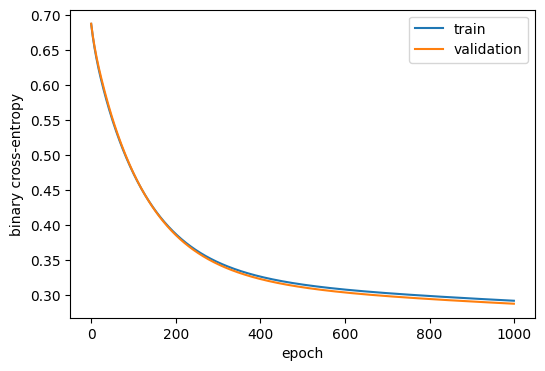

In [61]:
plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy")
plt.legend()
plt.show()


In [62]:
with torch.no_grad():
    beta_hat = model.beta.detach().cpu()
    beta_param_hat = model.beta_param.detach().cpu()

beta_df = pd.DataFrame({
    "parameter": BETA_LABELS,
    "estimate_beta": beta_hat.numpy(),
    "internal_beta_param": beta_param_hat.numpy(),
    "constraint": BETA_CONSTRAINT,
})
beta_df


,parameter,estimate_beta,internal_beta_param,constraint
0,beta_1: net_rur,0.599437,0.599437,unconstrained
1,beta_2: net_rsr,0.376474,0.376474,unconstrained
2,beta_3: net_rtr,0.323284,0.323284,unconstrained


In [63]:
masks = {"train": train_mask, "validation": val_mask, "test": test_mask}

metrics_05 = evaluate_splits(
    model=model, S_sym=S_sym, X=X, y01=y01, masks=masks, threshold=0.5, device=device
)
metrics_05


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.5,32167,0.146921,0.881120,0.621002,0.803499,0.252645,0.384417,27149,292,3532,1194,0.868967,0.603130,train
1,0.5,4595,0.141676,0.881175,0.610785,0.763819,0.233487,0.357647,3897,47,499,152,0.869811,0.583519,validation
2,0.5,9192,0.141427,0.886314,0.625063,0.801418,0.260769,0.393500,7808,84,961,339,0.869795,0.595550,test


In [64]:
prob = predict_prob(model, S_sym, X, device).numpy()
y_np = y01.numpy().astype(int)
val_idx = val_mask.numpy().astype(bool)

best_t_balacc, best_val_balacc = select_threshold(
    y_true=y_np[val_idx], score=prob[val_idx], objective="balanced_accuracy"
)
best_t_f1, best_val_f1 = select_threshold(
    y_true=y_np[val_idx], score=prob[val_idx], objective="f1"
)

print("Best validation threshold for balanced accuracy:", best_t_balacc, "value:", best_val_balacc)
print("Best validation threshold for F1:", best_t_f1, "value:", best_val_f1)


Best validation threshold for balanced accuracy: 0.14300000000000002 value: 0.7961444867157097
Best validation threshold for F1: 0.254 value: 0.5554780181437544


In [65]:
metrics_val_balacc = evaluate_splits(
    model=model, S_sym=S_sym, X=X, y01=y01, masks=masks,
    threshold=best_t_balacc, device=device
)
metrics_val_balacc


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.143,32167,0.146921,0.762676,0.786374,0.363577,0.819932,0.503770,20658,6783,851,3875,0.868967,0.603130,train
1,0.143,4595,0.141676,0.763439,0.796144,0.357702,0.841782,0.502061,2960,984,103,548,0.869811,0.583519,validation
2,0.143,9192,0.141427,0.767733,0.787634,0.358714,0.815385,0.498237,5997,1895,240,1060,0.869795,0.595550,test


In [66]:
metrics_val_f1 = evaluate_splits(
    model=model, S_sym=S_sym, X=X, y01=y01, masks=masks,
    threshold=best_t_f1, device=device
)
metrics_val_f1


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.254,32167,0.146921,0.860198,0.756394,0.520702,0.609395,0.561568,24790,2651,1846,2880,0.868967,0.603130,train
1,0.254,4595,0.141676,0.861371,0.757002,0.508951,0.611367,0.555478,3560,384,253,398,0.869811,0.583519,validation
2,0.254,9192,0.141427,0.862163,0.757171,0.510611,0.610769,0.556217,7131,761,506,794,0.869795,0.595550,test


In [ ]:
# Edit ROW_NAME before running if you want a custom label in the CSV.
from pathlib import Path

ROW_NAME = "S_gm_weighted_nn"

# For Colab, set SAVE_TO_GOOGLE_DRIVE=True and edit GOOGLE_DRIVE_METRICS_CSV_PATH.
SAVE_TO_GOOGLE_DRIVE = False
GOOGLE_DRIVE_METRICS_CSV_PATH = "/content/drive/MyDrive/yelp_s_metrics.csv"

if SAVE_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    METRICS_CSV_PATH = Path(GOOGLE_DRIVE_METRICS_CSV_PATH)
else:
    METRICS_CSV_PATH = Path("script/yelp/yelp_s_metrics.csv") if Path("script/yelp").exists() else Path("yelp_s_metrics.csv")


def append_test_metric_row(row_name, metric_frames, extra_metadata, csv_path=METRICS_CSV_PATH):
    csv_path = Path(csv_path)
    row = {"row_name": row_name, **extra_metadata}

    for metric_set, frame in metric_frames.items():
        test_rows = frame.loc[frame["split"].astype(str).str.lower().eq("test")]
        if test_rows.empty:
            raise ValueError(f"No test split found in {metric_set}")

        test_row = test_rows.iloc[0]
        prefix = metric_set.replace(".", "_")
        for column, value in test_row.items():
            if column == "split":
                continue
            row[f"{prefix}_{column}"] = value

    saved = pd.DataFrame([row])
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    saved.to_csv(csv_path, mode="a", header=not csv_path.exists(), index=False)
    print(f"Saved 1 test metric row to {csv_path}")
    return saved


metric_frames = {
    "threshold_0.5": metrics_05,
    "threshold_val_balanced_accuracy": metrics_val_balacc,
    "threshold_val_f1": metrics_val_f1,
}

run_metadata = {
    "notebook": "S_gm_weighted_nn.ipynb",
    "model_type": "symmetric_degree_normalized_similarity_weighted_mple",
    "external_field": EXTERNAL_FIELD,
    "beta_constraint": BETA_CONSTRAINT,
    "selected_threshold_balanced_accuracy": best_t_balacc,
    "selected_threshold_f1": best_t_f1,
}

saved_metric_row = append_test_metric_row(ROW_NAME, metric_frames, run_metadata)
saved_metric_row


In [21]:
results = {
    "model_type": "symmetric_degree_normalized_similarity_weighted_mple",
    "external_field": EXTERNAL_FIELD,
    "edge_types": EDGE_TYPES,
    "beta_constraint": BETA_CONSTRAINT,
    "tau_values": tau_values.numpy().tolist(),
    "beta_hat": beta_hat.numpy().tolist(),
    "fit_info": fit_info,
    "threshold_05_metrics": metrics_05.to_dict(orient="records"),
    "threshold_val_balanced_accuracy": best_t_balacc,
    "threshold_val_balanced_accuracy_metrics": metrics_val_balacc.to_dict(orient="records"),
    "threshold_val_f1": best_t_f1,
    "threshold_val_f1_metrics": metrics_val_f1.to_dict(orient="records"),
}
pd.Series(results)


model_type                                 symmetric_degree_normalized_similarity_weighte...
external_field                                                                        neural
edge_types                                                       [net_rur, net_rsr, net_rtr]
beta_constraint                                                                unconstrained
tau_values                                 [6.746762752532959, 7.5904412269592285, 7.5698...
beta_hat                                   [0.7110605835914612, 0.42840880155563354, 0.27...
fit_info                                   {'best_epoch': 999, 'best_val_loss': 0.2154316...
threshold_05_metrics                       [{'threshold': 0.5, 'n': 32167, 'positive_rate...
threshold_val_balanced_accuracy                                                        0.153
threshold_val_balanced_accuracy_metrics    [{'threshold': 0.153, 'n': 32167, 'positive_ra...
threshold_val_f1                                                      

In [22]:
# Monte Carlo credible intervals for P(sigma_i = +1) using Gibbs updates.
# Assumes the corrected symmetric-normalized notebook variables already exist:
# g, X, sigma_all, train_mask, val_mask, test_mask, EDGE_TYPES, tau_values,
# weighted_degrees, model, device.

import numpy as np
import pandas as pd
import torch
from scipy.stats import beta as beta_dist


@torch.no_grad()
def build_symmetric_normalized_csr(
    g,
    X,
    edge_types,
    tau_values,
    weighted_degrees,
    beta_hat,
    chunk_size=500_000,
    eps=1e-12,
    device=None,
):
    """
    Builds a CPU CSR representation of the fitted graph interaction matrix.

    For each relation r, the coefficient from i to j is

        beta_r A_ij^(r) w_ij^(r) / sqrt((D_i^(r)+eps)(D_j^(r)+eps)).

    The output represents the sparse matrix J, where

        graph_field_i = sum_j J_ij sigma_j.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_dev = X.to(device).float()
    D_dev = weighted_degrees.to(device).float().clamp_min(eps)
    beta_dev = beta_hat.to(device).float()

    n = X.shape[0]

    src_parts = []
    dst_parts = []
    coef_parts = []

    for r, etype in enumerate(edge_types):
        src0, dst0 = g.edges(etype=etype)

        # Explicitly symmetrize.
        src_cpu = torch.cat([src0, dst0], dim=0)
        dst_cpu = torch.cat([dst0, src0], dim=0)

        m = src_cpu.numel()
        tau_r = float(tau_values[r])
        beta_r = beta_dev[r]

        for start in range(0, m, chunk_size):
            end = min(start + chunk_size, m)

            src = src_cpu[start:end].to(device)
            dst = dst_cpu[start:end].to(device)

            dist2 = (X_dev[src] - X_dev[dst]).pow(2).sum(dim=1)
            w = torch.exp(-dist2 / (2.0 * tau_r**2))

            coef = beta_r * w / torch.sqrt(D_dev[src, r] * D_dev[dst, r])

            src_parts.append(src.detach().cpu())
            dst_parts.append(dst.detach().cpu())
            coef_parts.append(coef.detach().cpu())

    src_all = torch.cat(src_parts).long()
    dst_all = torch.cat(dst_parts).long()
    coef_all = torch.cat(coef_parts).float()

    order = torch.argsort(src_all)
    src_all = src_all[order]
    dst_all = dst_all[order]
    coef_all = coef_all[order]

    counts = torch.bincount(src_all, minlength=n)
    indptr = torch.zeros(n + 1, dtype=torch.long)
    indptr[1:] = torch.cumsum(counts, dim=0)

    return indptr, dst_all, coef_all


@torch.no_grad()
def compute_external_field(model, X, device=None):
    """
    Returns the fitted external field b_theta(X_i).
    The Gibbs local field uses 2 b_theta(X_i).
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    return model.field(X.to(device).float()).detach().cpu().float()


def gibbs_marginal_intervals(
    indptr,
    dst,
    coef,
    external_field,
    sigma_initial,
    observed_mask,
    num_sweeps=1000,
    burn_in=300,
    thinning=5,
    ci_level=0.95,
    seed=717,
):
    """
    Gibbs-samples from the fitted model conditional on observed training labels.

    Returns:
        posterior_df with estimated P(sigma_i=+1) and Monte Carlo credible intervals.

    The interval uses a Beta(1/2,1/2) posterior for the Bernoulli marginal
    based on retained MCMC samples. This does not account for MCMC autocorrelation,
    so increase thinning / sweeps if needed.
    """
    rng = np.random.default_rng(seed)

    n = sigma_initial.numel()
    sigma = sigma_initial.detach().cpu().float().clone()

    observed_mask = observed_mask.detach().cpu().bool()
    free_nodes = torch.where(~observed_mask)[0].numpy()

    ext = external_field.detach().cpu().float()
    indptr_np = indptr.numpy()
    dst_np = dst.numpy()
    coef_np = coef.numpy()
    sigma_np = sigma.numpy()
    ext_np = ext.numpy()

    retained = []

    for sweep in range(num_sweeps):
        rng.shuffle(free_nodes)

        for i in free_nodes:
            start = indptr_np[i]
            end = indptr_np[i + 1]

            if end > start:
                graph_field = np.dot(coef_np[start:end], sigma_np[dst_np[start:end]])
            else:
                graph_field = 0.0

            h_i = graph_field + 2.0 * ext_np[i]
            p_plus = 1.0 / (1.0 + np.exp(-2.0 * h_i))

            sigma_np[i] = 1.0 if rng.random() < p_plus else -1.0

        # Re-clamp observed labels exactly.
        sigma_np[observed_mask.numpy()] = sigma_initial.detach().cpu().numpy()[observed_mask.numpy()]

        if sweep >= burn_in and ((sweep - burn_in) % thinning == 0):
            retained.append((sigma_np == 1.0).astype(np.float32).copy())

        if sweep % 50 == 0:
            print(f"sweep {sweep:4d} / {num_sweeps}")

    samples = np.stack(retained, axis=0)
    m = samples.shape[0]

    successes = samples.sum(axis=0)
    p_hat = successes / m

    alpha = 0.5
    lower_q = (1.0 - ci_level) / 2.0
    upper_q = 1.0 - lower_q

    ci_lower = beta_dist.ppf(lower_q, successes + alpha, m - successes + alpha)
    ci_upper = beta_dist.ppf(upper_q, successes + alpha, m - successes + alpha)

    posterior_df = pd.DataFrame({
        "node": np.arange(n),
        "p_hat_sigma_plus_1": p_hat,
        f"ci_lower_{ci_level:.2f}": ci_lower,
        f"ci_upper_{ci_level:.2f}": ci_upper,
        "observed_training_label": observed_mask.numpy(),
        "sigma_true": sigma_initial.detach().cpu().numpy(),
    })

    return posterior_df, samples


# Build fitted graph interaction matrix.
with torch.no_grad():
    beta_hat = model.beta.detach().cpu()

indptr, dst, coef = build_symmetric_normalized_csr(
    g=g,
    X=X,
    edge_types=EDGE_TYPES,
    tau_values=tau_values,
    weighted_degrees=weighted_degrees,
    beta_hat=beta_hat,
    chunk_size=500_000,
    eps=DEGREE_EPS,
    device=device,
)

external_field = compute_external_field(model, X, device=device)

# Initialize unknown labels from the fitted plug-in probability, then clamp training labels.
with torch.no_grad():
    init_prob = predict_prob(model, S_sym, X, device).detach().cpu()
sigma_init = torch.where(init_prob >= 0.5, torch.ones_like(sigma_all), -torch.ones_like(sigma_all))
sigma_init[train_mask] = sigma_all[train_mask]

posterior_df, gibbs_samples = gibbs_marginal_intervals(
    indptr=indptr,
    dst=dst,
    coef=coef,
    external_field=external_field,
    sigma_initial=sigma_init,
    observed_mask=train_mask,
    num_sweeps=1000,
    burn_in=300,
    thinning=5,
    ci_level=0.95,
    seed=SEED,
)

posterior_df.head()

sweep    0 / 1000
sweep   50 / 1000
sweep  100 / 1000
sweep  150 / 1000
sweep  200 / 1000
sweep  250 / 1000
sweep  300 / 1000
sweep  350 / 1000
sweep  400 / 1000
sweep  450 / 1000
sweep  500 / 1000
sweep  550 / 1000
sweep  600 / 1000
sweep  650 / 1000
sweep  700 / 1000
sweep  750 / 1000
sweep  800 / 1000
sweep  850 / 1000
sweep  900 / 1000
sweep  950 / 1000


,node,p_hat_sigma_plus_1,ci_lower_0.95,ci_upper_0.95,observed_training_label,sigma_true
0,0,0.071429,0.037314,0.122996,False,-1.0
1,1,0.000000,0.000004,0.017751,True,-1.0
2,2,0.000000,0.000004,0.017751,True,-1.0
3,3,0.342857,0.268076,0.424061,False,1.0
4,4,0.135714,0.086607,0.199689,False,-1.0
